<a href="https://colab.research.google.com/github/aarav06-bit/CS131_release/blob/master/data_testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from ase.build import bulk

from scipy.ndimage import gaussian_filter
from scipy.ndimage import rotate

In [5]:
ELEMENTS = {

    'Au': {
        'mass': 196.97,
        'lattice_constant': 4.08,
        'structure': 'fcc'
    },

    'Al': {
        'mass': 26.98,
        'lattice_constant': 4.05,
        'structure': 'fcc'
    },

    'Fe': {
        'mass': 55.85,
        'lattice_constant': 2.87,
        'structure': 'bcc'
    },

    'Cu': {
        'mass': 63.55,
        'lattice_constant': 3.61,
        'structure': 'fcc'
    }
}

In [6]:
AVOGADRO = 6.022e23

ATOMS_PER_CELL = {
    'fcc': 4,
    'bcc': 2,
    'hcp': 6
}

def compute_density(structure, mass, lattice_constant):

    n = ATOMS_PER_CELL[structure]

    # convert angstroms to cm
    a_cm = lattice_constant * 1e-8

    volume = a_cm**3

    density = (n * mass) / (AVOGADRO * volume)

    return density

In [7]:
def generate_crystal_image(
    element='Au',
    repetitions=(8,8,4),
    grid_size=128,
    sigma=2,
    noise_level=0.01,
    rotation_angle=0
):

    info = ELEMENTS[element]

    structure = info['structure']
    lattice_constant = info['lattice_constant']
    mass = info['mass']

    # Create crystal
    atoms = bulk(
        element,
        structure,
        a=lattice_constant
    )

    atoms = atoms.repeat(repetitions)

    # Atomic positions
    positions = atoms.get_positions()

    x = positions[:,0]
    y = positions[:,1]

    # Normalize coordinates
    x_norm = (x - x.min()) / (x.max() - x.min())
    y_norm = (y - y.min()) / (y.max() - y.min())

    # Create image
    image = np.zeros((grid_size, grid_size))

    x_pix = (x_norm * (grid_size - 1)).astype(int)
    y_pix = (y_norm * (grid_size - 1)).astype(int)

    # Place atoms
    for xp, yp in zip(x_pix, y_pix):
        image[yp, xp] += 1

    # Gaussian blur
    image = gaussian_filter(image, sigma=sigma)

    # Rotate image
    image = rotate(
        image,
        angle=rotation_angle,
        reshape=False
    )

    # Add Gaussian noise
    noise = np.random.normal(
        0,
        noise_level,
        image.shape
    )

    image = image + noise

    # Normalize image
    image = image - image.min()
    image = image / image.max()

    # Compute density
    density = compute_density(
        structure,
        mass,
        lattice_constant
    )

    metadata = {
        'element': element,
        'structure': structure,
        'density': density
    }

    return image, metadata

{'element': 'Au', 'structure': 'fcc', 'density': 19.263661391121232}


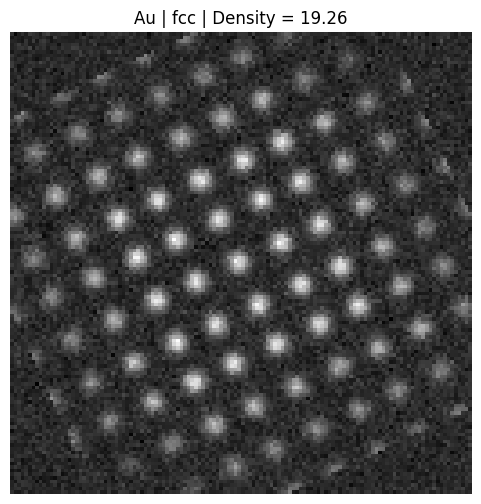

In [8]:
image, metadata = generate_crystal_image(
    element='Au',
    rotation_angle=25
)

print(metadata)

plt.figure(figsize=(6,6))

plt.imshow(image, cmap='gray')

plt.title(
    f"{metadata['element']} | "
    f"{metadata['structure']} | "
    f"Density = {metadata['density']:.2f}"
)

plt.axis('off')

plt.show()